# Uber_Data_Analysis_Project

In [2]:
# Suppose you work in data analysis at uber; you need to provide answers to all the questions given below to the company.

# 1.) In which category do people book the most uber rides? 
# 2.) For which purpose do people book Uber rides the most?
# 3.) At what time do people book cabs the most from uber?
# 4.) In which months do people book uber rides less frequently?
# 5.) On which days of the week do people book Uber rides the most?
# 6.) How many miles do people usually book a cab for through uber?

# Importing all Neccessary Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Creating Dataframes

In [4]:
df = pd.read_csv("UberDataset.csv")

In [5]:
df.head(7)

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
5,01-06-2016 17:15,01-06-2016 17:19,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain
6,01-06-2016 17:30,01-06-2016 17:35,Business,West Palm Beach,Palm Beach,7.1,Meeting


# Exploratory Data Analysis(EDA)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


In [7]:
df.duplicated().sum()

np.int64(1)

In [8]:
df.shape

(1156, 7)

In [9]:
# Exploration Summary

# Start Date and End Date is given is given in object form. which should be convert in type of date.
# In Start and End Date columns time is mixed up with date, so we have to seperate them.
# In purpose column there is also more than one purpose is given in the column.
# End Date column of df date is not neecessary so we have to remove it.
# And in last we have to add one more coloumn which is of adding wekkely Days.

# Data Preprocessing

Date and Time conversion

In [10]:
df['START_DATE'] = pd.to_datetime(df['START_DATE'], errors="coerce")
df['END_DATE'] = pd.to_datetime(df['END_DATE'], errors = "coerce")

In [11]:
from datetime import datetime

df['DATE'] = pd.DatetimeIndex(df['START_DATE']).date
df['TIME'] = pd.DatetimeIndex(df['START_DATE']).hour

In [12]:
def get_time_period(hour):
    if hour > 0 and hour <= 10:
        return 'MORNING'
        
    elif hour > 10 and hour <= 15:
        return 'AFTERNOON'

    elif hour > 15 and hour <= 19:
        return 'EVENING'

    else:
        return 'NIGHT'

In [13]:
df['TIME_PERIOD'] = df['TIME'].apply(get_time_period)

In [14]:
df['PURPOSE'] = df['PURPOSE'].fillna("Unknown")

In [15]:
df.shape

(1156, 10)

In [16]:
colos = ['START_DATE', 'END_DATE', 'START', 'STOP']
df.drop(colos, axis= 1, inplace= True)

In [17]:
Colos = ['TIME']
df.drop(Colos, axis = 1, inplace = True)

In [18]:
df.head()

,CATEGORY,MILES,PURPOSE,DATE,TIME_PERIOD
0,Business,5.1,Meal/Entertain,2016-01-01,NIGHT
1,Business,5.0,Unknown,2016-01-02,MORNING
2,Business,4.8,Errand/Supplies,2016-01-02,NIGHT
3,Business,4.7,Meeting,2016-01-05,EVENING
4,Business,63.7,Customer Visit,2016-01-06,AFTERNOON


In [19]:
df["DATE"] = pd.to_datetime(df["DATE"])

In [20]:
df["DAY"] = df["DATE"].dt.day_name()

In [21]:
df.head()

,CATEGORY,MILES,PURPOSE,DATE,TIME_PERIOD,DAY
0,Business,5.1,Meal/Entertain,2016-01-01,NIGHT,Friday
1,Business,5.0,Unknown,2016-01-02,MORNING,Saturday
2,Business,4.8,Errand/Supplies,2016-01-02,NIGHT,Saturday
3,Business,4.7,Meeting,2016-01-05,EVENING,Tuesday
4,Business,63.7,Customer Visit,2016-01-06,AFTERNOON,Wednesday


In [22]:
df["MONTH"] = df["DATE"].dt.month_name()

In [23]:
df.drop("DATE", axis= 1, inplace= True)

In [24]:
df.head()

,CATEGORY,MILES,PURPOSE,TIME_PERIOD,DAY,MONTH
0,Business,5.1,Meal/Entertain,NIGHT,Friday,January
1,Business,5.0,Unknown,MORNING,Saturday,January
2,Business,4.8,Errand/Supplies,NIGHT,Saturday,January
3,Business,4.7,Meeting,EVENING,Tuesday,January
4,Business,63.7,Customer Visit,AFTERNOON,Wednesday,January


In [25]:
df.isnull().sum()

CATEGORY         1
MILES            0
PURPOSE          0
TIME_PERIOD      0
DAY            735
MONTH          735
dtype: int64

In [26]:
df["DAY"] = df["DAY"].fillna("Unknown")
df["MONTH"] = df["MONTH"].fillna("Unknown")

In [27]:
df.isnull().sum()

CATEGORY       1
MILES          0
PURPOSE        0
TIME_PERIOD    0
DAY            0
MONTH          0
dtype: int64

# In which category do people book the most uber rides? 

Mathematical Calculation

In [28]:
df['CATEGORY'].value_counts()

CATEGORY
Business    1078
Personal      77
Name: count, dtype: int64

Visulaziation

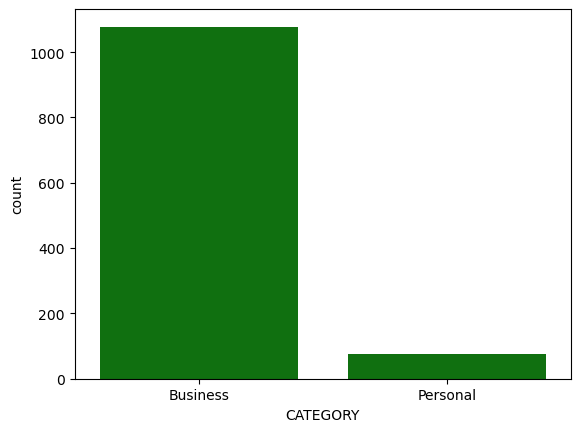

In [29]:
sns.countplot(x = df['CATEGORY'],color = "Green")
plt.show()

# For which purpose do people book Uber rides the most?

Mathematical Calculation

In [30]:
df['PURPOSE'].value_counts()

PURPOSE
Unknown            503
Meeting            187
Meal/Entertain     160
Errand/Supplies    128
Customer Visit     101
Temporary Site      50
Between Offices     18
Moving               4
Airport/Travel       3
Charity ($)          1
Commute              1
Name: count, dtype: int64

Visulaziation

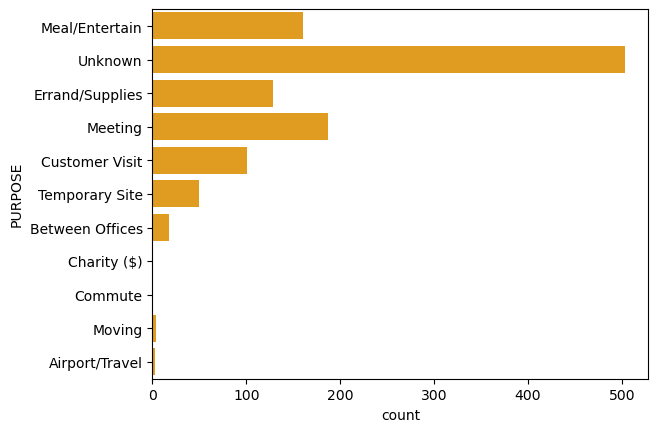

In [31]:
sns.countplot(y = df['PURPOSE'], color = 'orange')
plt.show()

# At what time do people book cabs the most from uber?

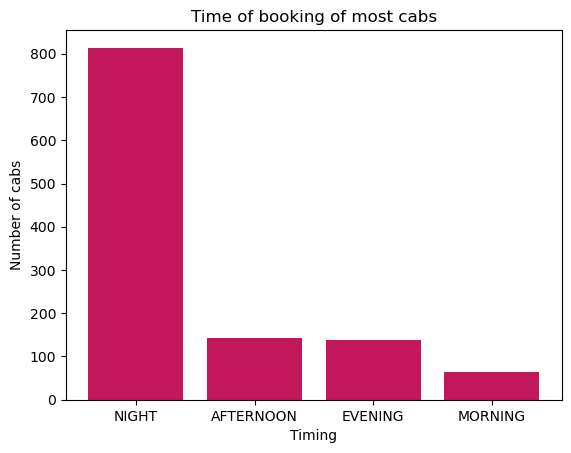

In [37]:
time_count = df['TIME_PERIOD'].value_counts()

plt.bar(time_count.index, time_count.values, color = "#C2185B")
plt.ylabel("Number of cabs")
plt.xlabel("Timing")
plt.title("Time of booking of most cabs")
plt.show()

# In which months do people book uber rides less frequently?

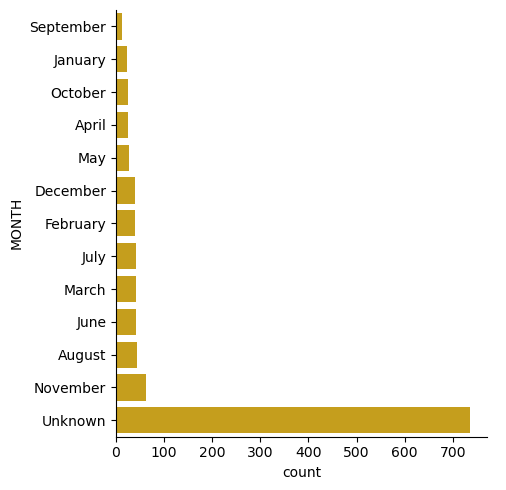

In [43]:
sns.catplot(y = "MONTH", data = df, kind= "count",
            order = df["MONTH"].value_counts().sort_values().index,
            color = "#E1AD01")
plt.show()

# On which days of the week do people book Uber rides the most?

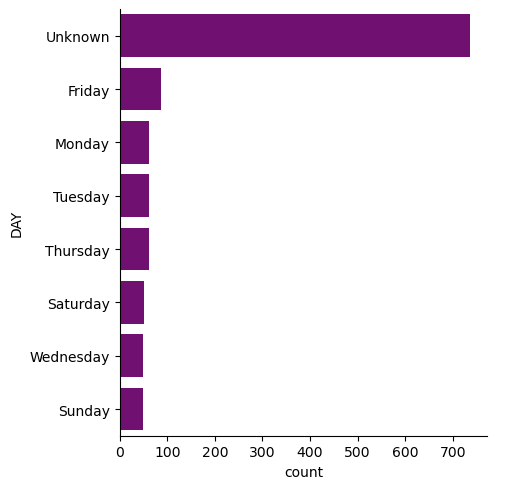

In [47]:
sns.catplot(y = "DAY", data = df, kind = "count",
            order = df["DAY"].value_counts().index,
            color = "purple")
plt.show()

# How many miles do people usually book a cab for through uber?

In [48]:
df.head()

,CATEGORY,MILES,PURPOSE,TIME_PERIOD,DAY,MONTH
0,Business,5.1,Meal/Entertain,NIGHT,Friday,January
1,Business,5.0,Unknown,MORNING,Saturday,January
2,Business,4.8,Errand/Supplies,NIGHT,Saturday,January
3,Business,4.7,Meeting,EVENING,Tuesday,January
4,Business,63.7,Customer Visit,AFTERNOON,Wednesday,January


In [50]:
df.describe()

,MILES
count,1156.000000
mean,21.115398
std,359.299007
min,0.500000
25%,2.900000
50%,6.000000
75%,10.400000
max,12204.700000


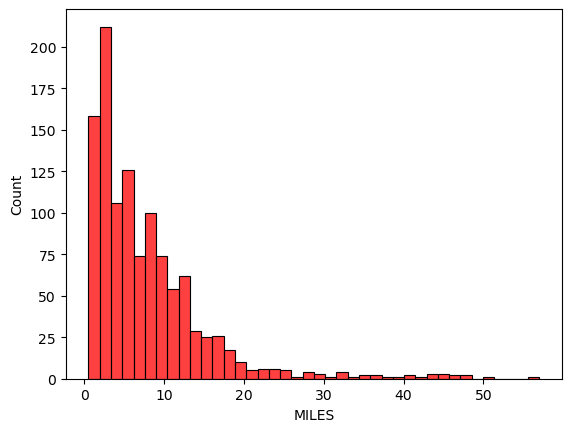

In [55]:
sns.histplot(data= df[df["MILES"] < 60], color = "Red", x = "MILES")
plt.show()